
Decision Tree - Feature Extracted Data
              precision    recall  f1-score   support

           0       0.51      0.04      0.08      6607
           1       0.82      0.99      0.90     29429

    accuracy                           0.82     36036
   macro avg       0.66      0.52      0.49     36036
weighted avg       0.76      0.82      0.75     36036



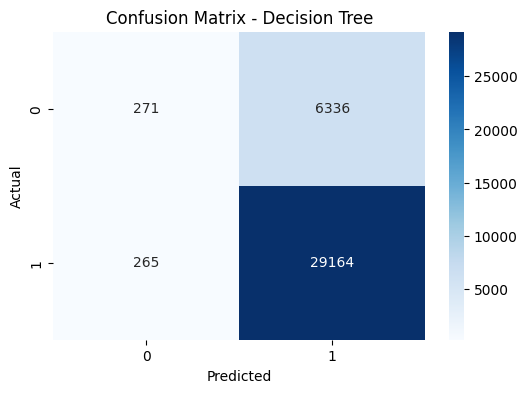

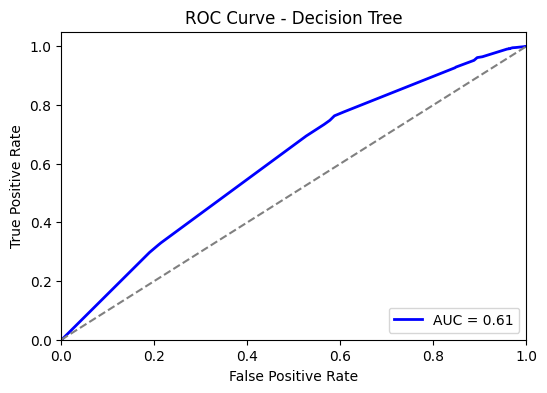


Random Forest - Feature Extracted Data
              precision    recall  f1-score   support

           0       0.39      0.19      0.25      6607
           1       0.84      0.93      0.88     29429

    accuracy                           0.80     36036
   macro avg       0.61      0.56      0.57     36036
weighted avg       0.75      0.80      0.77     36036



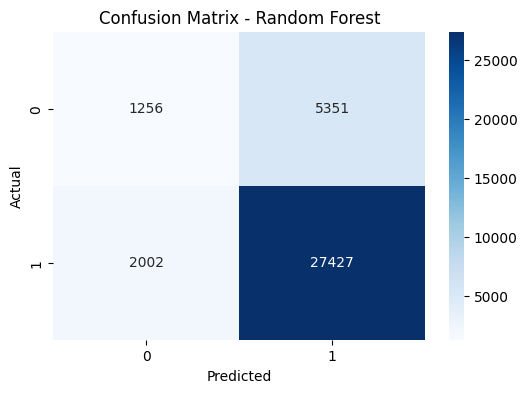

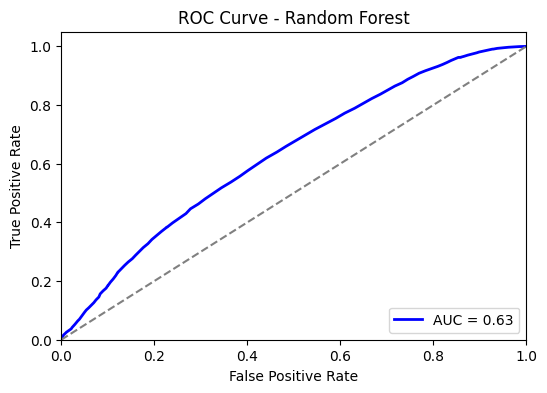


KNN - Feature Extracted Data
              precision    recall  f1-score   support

           0       0.37      0.16      0.23      6607
           1       0.83      0.94      0.88     29429

    accuracy                           0.80     36036
   macro avg       0.60      0.55      0.55     36036
weighted avg       0.75      0.80      0.76     36036



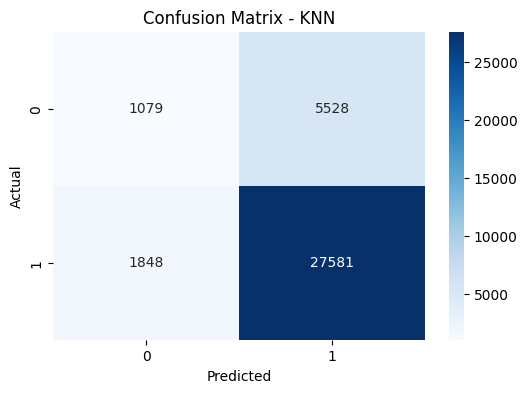

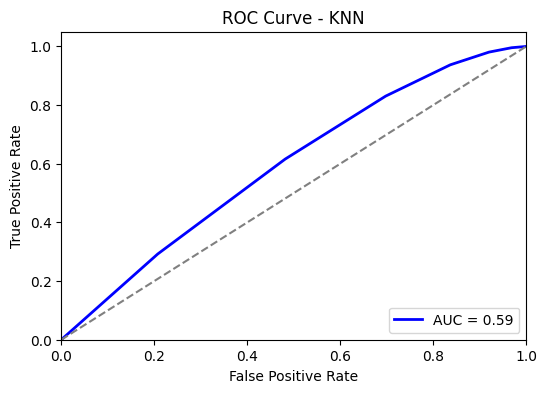

C:\Users\Jayanth C R\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression - Feature Extracted Data
              precision    recall  f1-score   support

           0       0.43      0.06      0.10      6607
           1       0.82      0.98      0.90     29429

    accuracy                           0.81     36036
   macro avg       0.63      0.52      0.50     36036
weighted avg       0.75      0.81      0.75     36036



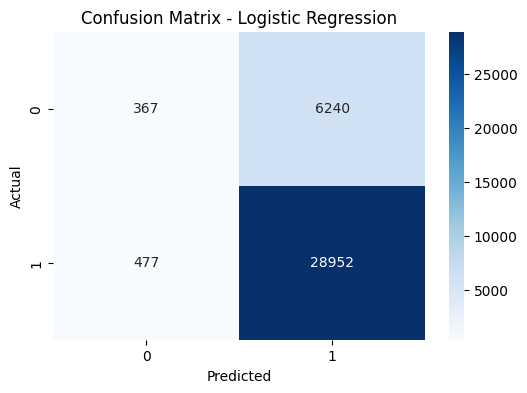

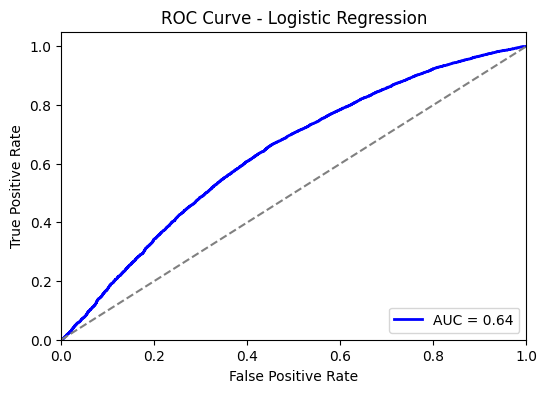

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten
import keras_tuner as kt

# Corrected function with absolute paths
def load_feature_data():
    base_path = r"D:\Amrita\Sem-4\Machine Learning Lab\End Sem Project\Excel\5. Splitting"
    
    X_train = pd.read_csv(os.path.join(base_path, "X_train.csv"))
    y_train = pd.read_csv(os.path.join(base_path, "y_train.csv")).values.ravel()
    X_test = pd.read_csv(os.path.join(base_path, "X_test.csv"))
    y_test = pd.read_csv(os.path.join(base_path, "y_test.csv")).values.ravel()
    
    return X_train, y_train, X_test, y_test

def preprocess_data(X_train, X_test):
    X_test = X_test[X_train.columns]  # Ensure same columns and order
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

def plot_roc_curve(y_test, y_scores, model_name):
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc='lower right')
    plt.show()

def train_and_evaluate_models(X_train, y_train, X_test, y_test, dataset_type="Feature Extracted"):
    models = {
        "Decision Tree": (DecisionTreeClassifier(), {'max_depth': [5, 10, 20]}),
        "Random Forest": (RandomForestClassifier(), {'n_estimators': [50, 100, 200]}),
        "KNN": (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
        "Logistic Regression": (LogisticRegression(), {'C': [0.1, 1, 10]}),
        "SVM (Linear)": (SVC(kernel='linear', probability=True), {'C': [0.1, 1, 10]}),
        "SVM (RBF)": (SVC(kernel='rbf', probability=True), {'C': [0.1, 1, 10]}),
        "ANN (ReLU)": (MLPClassifier(max_iter=500), {'hidden_layer_sizes': [(50,), (100,), (100, 50)]})
    }
    
    for name, (model, params) in models.items():
        best_model = GridSearchCV(model, params, scoring='accuracy', cv=5, n_jobs=-1)
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
        y_scores = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else best_model.decision_function(X_test)
        
        print(f"\n{name} - {dataset_type} Data")
        print(classification_report(y_test, y_pred))
        
        plot_confusion_matrix(y_test, y_pred, name)
        plot_roc_curve(y_test, y_scores, name)

# Load and preprocess feature data
X_train, y_train, X_test, y_test = load_feature_data()
X_train, X_test = preprocess_data(X_train, X_test)
train_and_evaluate_models(X_train, y_train, X_test, y_test, dataset_type="Feature Extracted")
